In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df = pd.read_csv("../XSS_dataset.csv")
texts = df['text'].values
labels = df['label'].values
print(f"Всего примеров: {len(texts)}")

Всего примеров: 13686


In [4]:
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)

In [5]:
MAX_LEN = 200
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Форма обучающих данных: {X_train_pad.shape}")

Форма обучающих данных: (10948, 200)


In [6]:
model = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\учёба\SSRW\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('lstm_xss_best.h5', monitor='val_accuracy', save_best_only=True)

In [8]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.8520 - loss: 0.3146

137/137 ━━━━━━━━━━━━━━━━━━━━ 52s 335ms/step - accuracy: 0.9496 - loss: 0.1324 - val_accuracy: 0.9963 - val_loss: 0.0108
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.9946 - loss: 0.0191

137/137 ━━━━━━━━━━━━━━━━━━━━ 45s 325ms/step - accuracy: 0.9959 - loss: 0.0149 - val_accuracy: 0.9986 - val_loss: 0.0050
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.9985 - loss: 0.0073

137/137 ━━━━━━━━━━━━━━━━━━━━ 45s 325ms/step - accuracy: 0.9984 - loss: 0.0065 - val_accuracy: 0.9995 - val_loss: 0.0038
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 43s 314ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9991 - val_loss: 0.0021
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 43s 310ms/step - accuracy: 0.9993 - loss: 0.0020 - val_accuracy: 0.9991 - val_loss: 0.0027
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9995 - loss: 0.0015

137/137 ━━━━━━━━━━━━━━━━━━━━ 43s 311ms/step - accuracy: 0.9998 - loss: 9.1591e-04 - val_accuracy: 1.0000 - val_loss: 3.2609e-04
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 309ms/step - accuracy: 0.9995 - loss: 0.0011 - val_accuracy: 0.9991 - val_loss: 0.0015
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - accuracy: 1.0000 - loss: 3.5858e-04 - val_accuracy: 1.0000 - val_loss: 1.9922e-04
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 309ms/step - accuracy: 0.9999 - loss: 2.4682e-04 - val_accuracy: 1.0000 - val_loss: 1.4236e-04
Epoch 10/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 309ms/step - accuracy: 0.9999 - loss: 2.7519e-04 - val_accuracy: 1.0000 - val_loss: 1.8161e-04


In [9]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n=== Отчёт ===")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

=== Отчёт ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

AUC: 1.0000


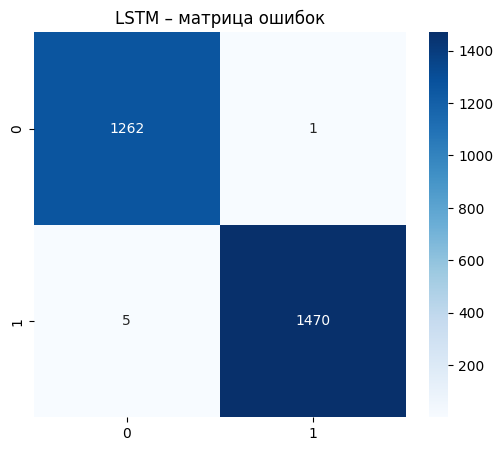

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM – матрица ошибок")
plt.savefig("lstm_confusion.png")
plt.show()

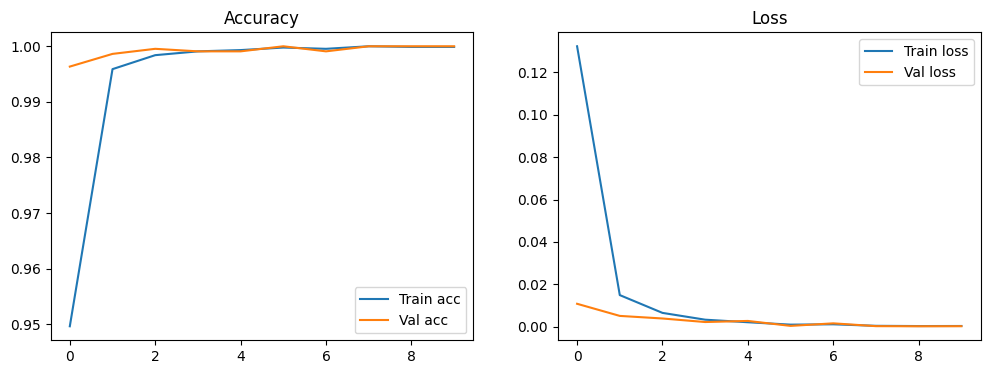

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.title('Loss')
plt.savefig("lstm_training_curves.png")
plt.show()

In [12]:
joblib.dump(tokenizer, "lstm_tokenizer.pkl")
model.save("lstm_xss_model.h5")
print("Модель и токенизатор сохранены.")

Модель и токенизатор сохранены.



ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (LSTM)
414/414 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step
              precision    recall  f1-score   support

           0       0.98      0.57      0.72      6613
           1       0.70      0.99      0.82      6613

    accuracy                           0.78     13226
   macro avg       0.84      0.78      0.77     13226
weighted avg       0.84      0.78      0.77     13226

AUC: 0.9925


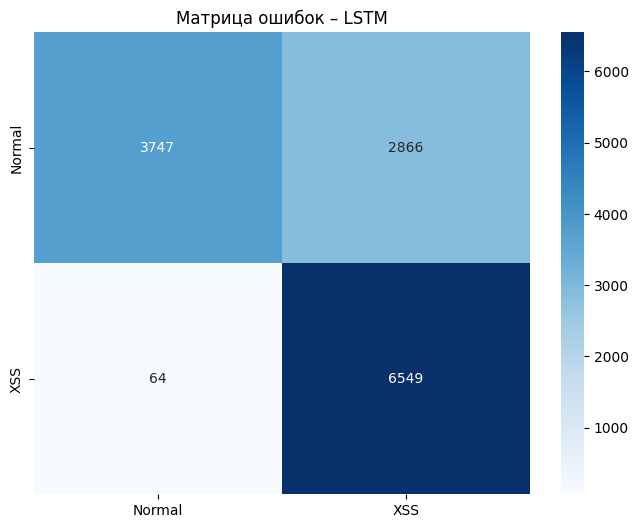

<script>alert('XSS')</script>: XSS=False (prob=0.12%)
<div>Hello</div>: XSS=False (prob=0.13%)


In [13]:
# ========== БЛОК ОЦЕНКИ НА ТЕСТОВОМ ДАТАСЕТЕ (LSTM) ==========
print("\n" + "="*60)
print("ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (LSTM)")
print("="*60)

test_df = pd.read_csv("../datasets_test/xss_dataset.csv")
test_texts = test_df['text'].values
y_test_full = test_df['label'].values

# Токенизация и паддинг тестовых данных
test_seq = tokenizer.texts_to_sequences(test_texts)
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Предсказания
y_proba_full = model.predict(test_pad).flatten()
y_pred_full = (y_proba_full >= 0.5).astype(int)

# Метрики
print(classification_report(y_test_full, y_pred_full))
print(f"AUC: {roc_auc_score(y_test_full, y_proba_full):.4f}")

# Матрица ошибок
cm_full = confusion_matrix(y_test_full, y_pred_full)
plt.figure(figsize=(8,6))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'XSS'], yticklabels=['Normal', 'XSS'])
plt.title('Матрица ошибок – LSTM')
plt.savefig('lstm_test_confusion.png')
plt.show()

# Примеры
test_cases = [
    "<script>alert('XSS')</script>",
    "<div>Hello</div>"
]
for code in test_cases:
    seq = tokenizer.texts_to_sequences([code])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    prob = model.predict(pad, verbose=0)[0][0]
    print(f"{code[:40]}: XSS={prob>=0.5} (prob={prob:.2%})")